# Test results EDA — `test_results_27.csv`

Loads `test_results_27.csv` from the project root, parses `pcd_<n>` frame ids from `file_name`, and builds:

- **`df_frames`** — one row per partial scan (every potato × frame in the file).
- **`df_per_potato`** — per tuber: how many frames, min/max/**median** frame number, **median `exec_time_ms`** across frames.
- **`df_middle`** — one row per potato: the scan whose `frame_id` is **closest** to the median frame index for that potato (tie-break: smaller `frame_id`). Includes that row’s metrics plus **`median_exec_time_ms`** from `df_per_potato` for comparison.

In [8]:
from __future__ import annotations

from pathlib import Path
import pandas as pd

BASE = Path.cwd()
RESULT_PATH = BASE / "results/test_results_32.csv"

if not RESULT_PATH.is_file():
    raise FileNotFoundError(f"Missing {RESULT_PATH.resolve()}")

df_frames = pd.read_csv(RESULT_PATH)

m = df_frames["file_name"].astype(str).str.extract(r"pcd_(\d+)\.ply", expand=False)
if m.isna().any():
    bad = df_frames.loc[m.isna(), "file_name"].head(5).tolist()
    raise ValueError(f"Could not parse frame id from file_name (examples): {bad}")
df_frames["frame_id"] = m.astype(int)

df_frames = df_frames.sort_values(["unique_id", "frame_id"], kind="mergesort").reset_index(
    drop=True
)

# Show the median exec_time_ms over all rows, not per unique_id
median_exec_time_all = df_frames["exec_time_ms"].median()

print(f"Median exec_time_ms over all rows: {median_exec_time_all:.2f} ms")

Median exec_time_ms over all rows: 18.75 ms


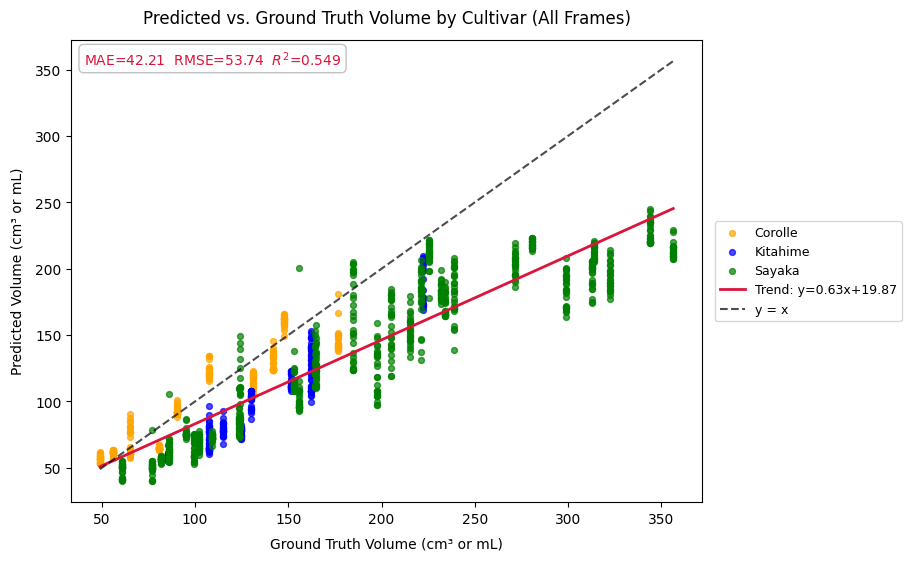

In [9]:
import matplotlib.pyplot as plt
from __future__ import annotations

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE = Path.cwd()
RESULT_PATH = BASE / "results/test_results_32.csv"

if not RESULT_PATH.is_file():
    raise FileNotFoundError(f"Missing {RESULT_PATH.resolve()}")

df_frames = pd.read_csv(RESULT_PATH)

cultivars = sorted(df_frames["cultivar"].dropna().unique())
custom_colors = ["orange", "blue", "green"]
colors = custom_colors[:len(cultivars)]

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

for i, cultivar in enumerate(cultivars):
    mask = df_frames["cultivar"] == cultivar
    ax.scatter(
        df_frames.loc[mask, "gt_volume_ml"],
        df_frames.loc[mask, "pred_volume_ml"],
        s=18,
        alpha=0.7,
        color=colors[i % len(colors)],
        label=str(cultivar)
    )

# Fit trend line (linear regression) on the true (gt_volume_ml, pred_volume_ml) pairs
X = df_frames["gt_volume_ml"].values.reshape(-1, 1)
y = df_frames["pred_volume_ml"].values
reg = LinearRegression().fit(X, y)

# Only use the regression result for the trend line and for the *metrics on the actual predictions*
# For error metrics, use the actual predictions (i.e., true vs predicted, not trend-fitted values)
# Compute regression line (trend) to plot
x_fit = np.array([df_frames["gt_volume_ml"].min(), df_frames["gt_volume_ml"].max()]).reshape(-1, 1)
y_fit = reg.predict(x_fit)
ax.plot(x_fit.flatten(), y_fit, color="crimson", lw=2, linestyle="-", label=f"Trend: y={reg.coef_[0]:.2f}x+{reg.intercept_:.2f}")

# Also plot the y=x identity line for comparison
vmin = df_frames["gt_volume_ml"].min()
vmax = df_frames["gt_volume_ml"].max()
ax.plot([vmin, vmax], [vmin, vmax], color='k', linestyle='--', alpha=0.7, label="y = x")

# Compute regression error metrics *between actual ground truth and predictions*, NOT trend values
mae = mean_absolute_error(df_frames["gt_volume_ml"].values, df_frames["pred_volume_ml"].values)
mse = mean_squared_error(df_frames["gt_volume_ml"].values, df_frames["pred_volume_ml"].values)
rmse = np.sqrt(mse)
r2 = r2_score(df_frames["gt_volume_ml"].values, df_frames["pred_volume_ml"].values)
metrics_text = f"MAE={mae:.2f}  RMSE={rmse:.2f}  $R^2$={r2:.3f}"

# Upper-left: usually clear on a y≈x scatter; keeps clear of legend (outside right)
ax.text(
    0.02,
    0.98,
    metrics_text,
    transform=ax.transAxes,
    fontsize=10,
    color="crimson",
    verticalalignment="top",
    horizontalalignment="left",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.95, edgecolor="0.75"),
)

ax.set_xlabel("Ground Truth Volume (cm³ or mL)", labelpad=8)
ax.set_ylabel("Predicted Volume (cm³ or mL)", labelpad=8)
ax.set_title("Predicted vs. Ground Truth Volume by Cultivar (All Frames)", pad=12)

# Outside plot on the right; constrained_layout reserves space for the legend
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=True,
    fontsize=9,
)

plt.show()

Partial axis flip (pre-PCA): (-1, -1, 1)  |  median dist partial->full: 1.57 mm


C:\Users\Jesper\AppData\Local\Temp\ipykernel_17788\3190581153.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


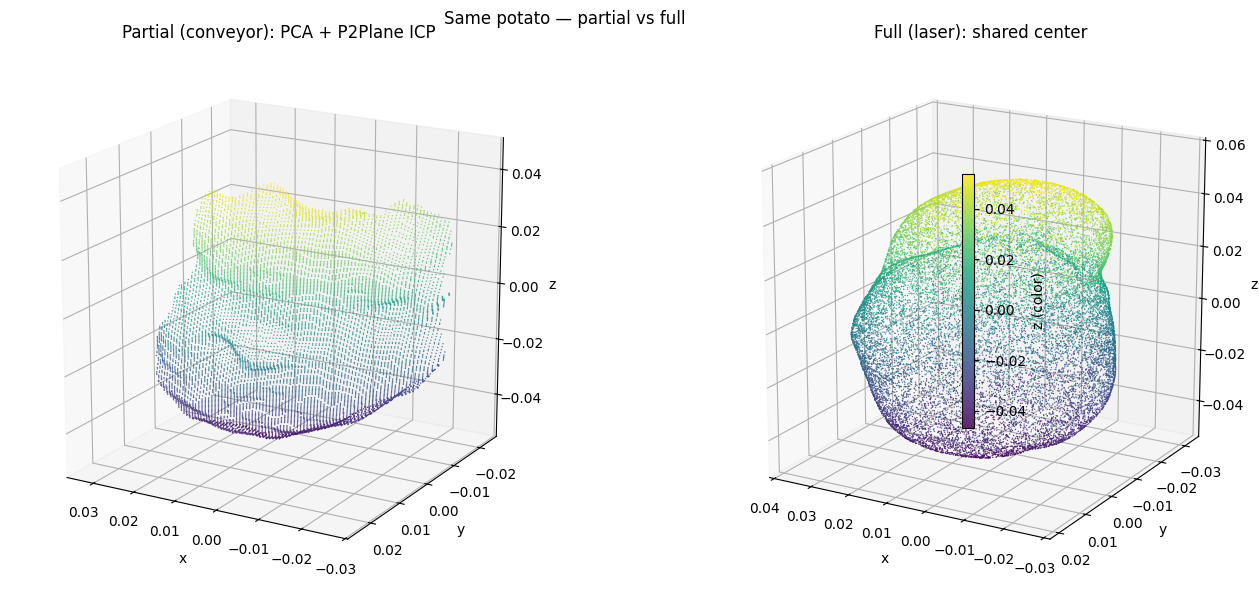

In [10]:
# Partial vs full point cloud — put matching `.ply` files next to this notebook and edit paths below.
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d

ROOT = Path(".").resolve()
PLY_PARTIAL = ROOT / "reviewdata/2025-000_pcd_355.ply"
PLY_FULL = ROOT / "reviewdata/2025-000_20000.ply"

pcd_partial_raw = o3d.io.read_point_cloud(str(PLY_PARTIAL))
pcd_full_raw = o3d.io.read_point_cloud(str(PLY_FULL))


def _pca_rotation_matrix(pts_p: np.ndarray, pts_f: np.ndarray) -> np.ndarray:
    _, _, v_partial = np.linalg.svd(pts_p, full_matrices=False)
    _, _, v_full = np.linalg.svd(pts_f, full_matrices=False)
    axes_p = v_partial.T
    axes_f = v_full.T
    r = axes_f @ axes_p.T
    if np.linalg.det(r) < 0:
        axes_f = axes_f.copy()
        axes_f[:, 2] *= -1
        r = axes_f @ axes_p.T
    return r


def _multiscale_point_to_plane_icp(
    pcd_source: o3d.geometry.PointCloud,
    pcd_target: o3d.geometry.PointCloud,
    extent: float,
) -> np.ndarray:
    """Coarse-to-fine point-to-plane ICP (surface alignment)."""
    voxel_base = max(extent * 0.03, 0.002)
    voxels = [voxel_base * 3.5, voxel_base * 1.8, voxel_base]
    max_iters = [60, 45, 35]
    trans = np.eye(4)
    for vox, mx in zip(voxels, max_iters):
        src = pcd_source.voxel_down_sample(vox)
        tgt = pcd_target.voxel_down_sample(vox)
        src.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=vox * 2.5, max_nn=40)
        )
        tgt.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=vox * 2.5, max_nn=40)
        )
        th = vox * 4.0
        reg = o3d.pipelines.registration.registration_icp(
            src,
            tgt,
            th,
            trans,
            o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=mx),
        )
        trans = reg.transformation
    return trans


def _median_distance_to_target(
    pcd_source: o3d.geometry.PointCloud, pcd_target: o3d.geometry.PointCloud
) -> float:
    d = np.asarray(pcd_source.compute_point_cloud_distance(pcd_target))
    return float(np.median(d))


def _align_one_flip(
    pcd_p_in: o3d.geometry.PointCloud,
    pcd_f_in: o3d.geometry.PointCloud,
    partial_flip: np.ndarray,
) -> tuple[o3d.geometry.PointCloud, o3d.geometry.PointCloud, float]:
    pts_p = (np.asarray(pcd_p_in.points) - np.asarray(pcd_p_in.points).mean(axis=0)) * partial_flip
    pts_f = np.asarray(pcd_f_in.points) - np.asarray(pcd_f_in.points).mean(axis=0)
    r = _pca_rotation_matrix(pts_p, pts_f)
    pts_p = pts_p @ r.T

    pcd_p = o3d.geometry.PointCloud()
    pcd_p.points = o3d.utility.Vector3dVector(pts_p)
    if pcd_p_in.has_colors():
        pcd_p.colors = pcd_p_in.colors
    pcd_f = o3d.geometry.PointCloud()
    pcd_f.points = o3d.utility.Vector3dVector(pts_f)
    if pcd_f_in.has_colors():
        pcd_f.colors = pcd_f_in.colors

    extent = max(np.ptp(pts_p, axis=0).max(), np.ptp(pts_f, axis=0).max())
    trans_icp = _multiscale_point_to_plane_icp(pcd_p, pcd_f, extent)
    pcd_p.transform(trans_icp)

    med = _median_distance_to_target(pcd_p, pcd_f)
    return pcd_p, pcd_f, med


def register_partial_to_full(
    pcd_partial: o3d.geometry.PointCloud, pcd_full: o3d.geometry.PointCloud
) -> tuple[np.ndarray, np.ndarray]:
    """Pick axis flip by lowest median partial->full distance; align with PCA + P2Plane ICP only."""
    best_med = None
    best_flip = None
    for sx in (-1.0, 1.0):
        for sy in (-1.0, 1.0):
            for sz in (-1.0, 1.0):
                flip = np.array([sx, sy, sz])
                _, _, med = _align_one_flip(
                    deepcopy(pcd_partial),
                    deepcopy(pcd_full),
                    flip,
                )
                if best_med is None or med < best_med:
                    best_med = med
                    best_flip = flip.copy()

    assert best_flip is not None
    pcd_p, pcd_f, med_final = _align_one_flip(pcd_partial, pcd_full, best_flip)

    pts_p = np.asarray(pcd_p.points)
    pts_f = np.asarray(pcd_f.points)
    center = np.vstack([pts_p, pts_f]).mean(axis=0)
    pts_p -= center
    pts_f -= center

    print(
        f"Partial axis flip (pre-PCA): ({best_flip[0]:.0f}, {best_flip[1]:.0f}, {best_flip[2]:.0f})  |  "
        f"median dist partial->full: {med_final*1000:.2f} mm"
    )
    return pts_p, pts_f


pts_partial_c, pts_full_c = register_partial_to_full(pcd_partial_raw, pcd_full_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})
titles = (
    "Partial (conveyor): PCA + P2Plane ICP",
    "Full (laser): shared center",
)
sc = None
elev, azim = 18, 120
for ax, pts, title in zip(axes, (pts_partial_c, pts_full_c), titles):
    sc = ax.scatter(
        pts[:, 0],
        pts[:, 1],
        pts[:, 2],
        c=pts[:, 2],
        cmap="viridis",
        s=1.0,
        alpha=0.85,
        linewidths=0,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
fig.colorbar(sc, ax=axes, shrink=0.55, label="z (color)")
fig.suptitle("Same potato — partial vs full")
plt.tight_layout()
plt.show()


In [11]:
# Interactive 3D (rotate / zoom / pan) — requires: pip install open3d plotly
# Run the cell above first: it defines pts_partial_c / pts_full_c (P2Plane + color ICP + shared center).
import numpy as np
import open3d as o3d

if "pts_partial_c" not in globals() or "pts_full_c" not in globals():
    raise RuntimeError("Run the previous cell first so the two clouds are registered and centered together.")

def numpy_to_pcd(pts: np.ndarray, color_rgb: tuple[float, float, float]) -> o3d.geometry.PointCloud:
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    n = pts.shape[0]
    cols = np.tile(np.array(color_rgb, dtype=np.float64), (n, 1))
    pcd.colors = o3d.utility.Vector3dVector(cols)
    return pcd


pcd_p = numpy_to_pcd(pts_partial_c, (1.0, 0.45, 0.1))
pcd_f = numpy_to_pcd(pts_full_c, (0.2, 0.5, 0.95))

# Both clouds in one Plotly scene — use the toolbar to orbit / zoom / reset camera
o3d.visualization.draw_plotly(
    [pcd_p, pcd_f],
    window_name="R9-9 partial (orange) vs full (blue)",
    width=950,
    height=700,
    point_sample_factor=1.0,
)

# Optional: native Open3D window (separate desktop window, full rendering controls)
# o3d.visualization.draw_geometries([pcd_p, pcd_f], window_name="R9-9", width=1280, height=720)
